## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [2]:
import pandas as pd
import geopandas as gpd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
from fuzzywuzzy import fuzz
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_EL = 'αττικης'

In [4]:
dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2010_2022.csv", encoding = enc)
dataset_monthly

FileNotFoundError: [Errno 2] No such file or directory: '../../data/Attica/GR_Attica_WNV_Dataset_NUTS3_2010_2022.csv'

<AxesSubplot:>

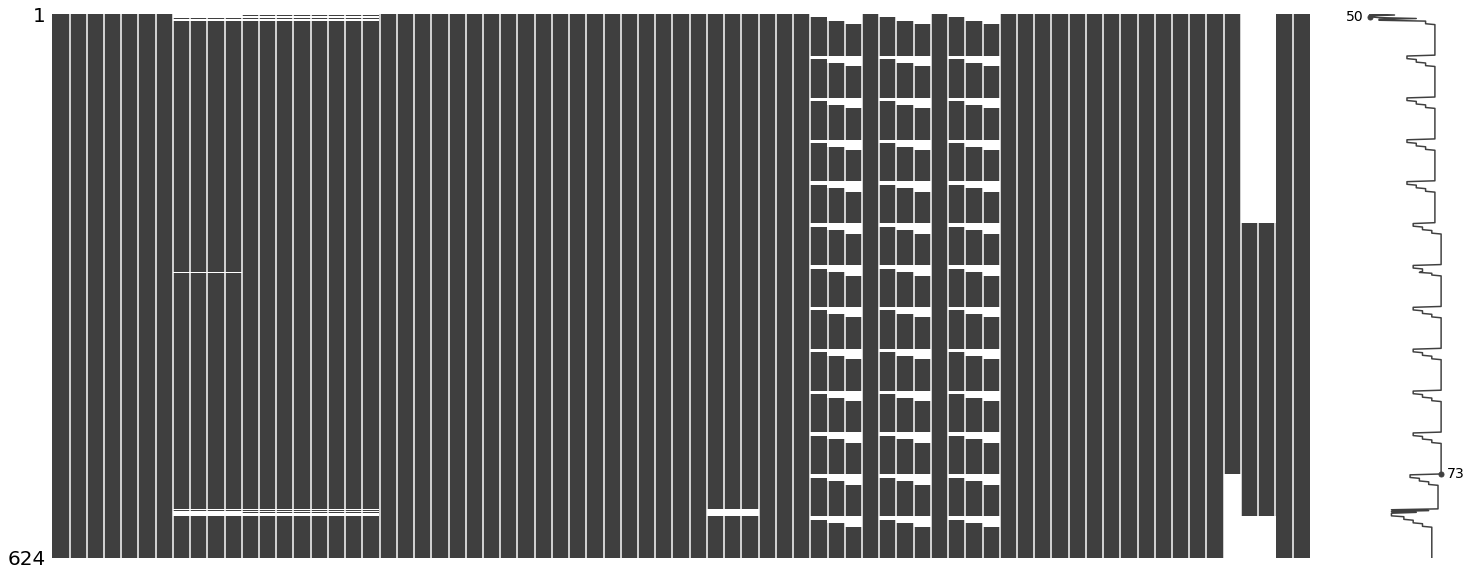

In [4]:
missingno.matrix(dataset_monthly)

In [5]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
0,ndvi,2.4038
1,ndmi,2.4038
2,ndwi,2.4038
3,ndbi,2.4038
4,ndvi_mean,1.9231
...,...,...
22,lst_night_mar_mean,16.6667
23,lst_night_apr_mean,25.0000
24,MIO_EUR,15.3846
25,L_TOTAL,46.1538


In [6]:
years = dataset_monthly.year.unique()
nuts3_units = dataset_monthly.nuts3.unique()

In [7]:
data = []

for year in years:
    for region in nuts3_units:
        filtered_df = dataset_monthly.loc[(dataset_monthly['year'] == year) & (dataset_monthly['nuts3'] == region)].copy()
        filtered_df.reset_index(drop = True, inplace = True)

        q1_df = filtered_df.loc[(filtered_df['month'] <= 3)]
        q2_df = filtered_df.loc[(filtered_df['month'] <= 6)]
        q3_df = filtered_df.loc[(filtered_df['month'] <= 9)]
        q4_df = filtered_df.loc[(filtered_df['month'] <= 12)]

        min_temp_q1 = q1_df['lst'].min()
        mean_temp_q1 = q1_df['lst'].mean()
        max_temp_q1 = q1_df['lst'].max()
        prec_q1 = q1_df['rainfall'].sum()

        ndvi_q1 = q1_df['ndvi'].mean()
        ndwi_q1 = q1_df['ndwi'].mean()
        ndmi_q1 = q1_df['ndmi'].mean()
        ndbi_q1 = q1_df['ndbi'].mean()

        ndvi_mean_q1 = q1_df['ndvi_mean'].mean()
        ndwi_mean_q1 = q1_df['ndwi_mean'].mean()
        ndmi_mean_q1 = q1_df['ndmi_mean'].mean()
        ndbi_mean_q1 = q1_df['ndbi_mean'].mean()

        ndvi_std_q1 = q1_df['ndvi_std'].mean()
        ndwi_std_q1 = q1_df['ndwi_std'].mean()
        ndmi_std_q1 = q1_df['ndmi_std'].mean()
        ndbi_std_q1 = q1_df['ndbi_std'].mean()

        min_temp_q2 = q2_df['lst'].min()
        mean_temp_q2 = q2_df['lst'].mean()
        max_temp_q2 = q2_df['lst'].max()
        prec_q2 = q2_df['rainfall'].sum()

        ndvi_q2 = q2_df['ndvi'].mean()
        ndwi_q2 = q2_df['ndwi'].mean()
        ndmi_q2 = q2_df['ndmi'].mean()
        ndbi_q2 = q2_df['ndbi'].mean()

        ndvi_mean_q2 = q2_df['ndvi_mean'].mean()
        ndwi_mean_q2 = q2_df['ndwi_mean'].mean()
        ndmi_mean_q2 = q2_df['ndmi_mean'].mean()
        ndbi_mean_q2 = q2_df['ndbi_mean'].mean()

        ndvi_std_q2 = q2_df['ndvi_std'].mean()
        ndwi_std_q2 = q2_df['ndwi_std'].mean()
        ndmi_std_q2 = q2_df['ndmi_std'].mean()
        ndbi_std_q2 = q2_df['ndbi_std'].mean()

        min_temp_q3 = q3_df['lst'].min()
        mean_temp_q3 = q3_df['lst'].mean()
        max_temp_q3 = q3_df['lst'].max()
        prec_q3 = q3_df['rainfall'].sum()

        ndvi_q3 = q3_df['ndvi'].mean()
        ndwi_q3 = q3_df['ndwi'].mean()
        ndmi_q3 = q3_df['ndmi'].mean()
        ndbi_q3 = q3_df['ndbi'].mean()

        ndvi_mean_q3 = q3_df['ndvi_mean'].mean()
        ndwi_mean_q3 = q3_df['ndwi_mean'].mean()
        ndmi_mean_q3 = q3_df['ndmi_mean'].mean()
        ndbi_mean_q3 = q3_df['ndbi_mean'].mean()

        ndvi_std_q3 = q3_df['ndvi_std'].mean()
        ndwi_std_q3 = q3_df['ndwi_std'].mean()
        ndmi_std_q3 = q3_df['ndmi_std'].mean()
        ndbi_std_q3 = q3_df['ndbi_std'].mean()

        min_temp_q4 = q4_df['lst'].min()
        mean_temp_q4 = q4_df['lst'].mean()
        max_temp_q4 = q4_df['lst'].max()
        prec_q4 = q4_df['rainfall'].sum()

        ndvi_q4 = q4_df['ndvi'].mean()
        ndwi_q4 = q4_df['ndwi'].mean()
        ndmi_q4 = q4_df['ndmi'].mean()
        ndbi_q4 = q4_df['ndbi'].mean()

        ndvi_mean_q4 = q4_df['ndvi_mean'].mean()
        ndwi_mean_q4 = q4_df['ndwi_mean'].mean()
        ndmi_mean_q4 = q4_df['ndmi_mean'].mean()
        ndbi_mean_q4 = q4_df['ndbi_mean'].mean()

        ndvi_std_q4 = q4_df['ndvi_std'].mean()
        ndwi_std_q4 = q4_df['ndwi_std'].mean()
        ndmi_std_q4 = q4_df['ndmi_std'].mean()
        ndbi_std_q4 = q4_df['ndbi_std'].mean()

        data.append({'nuts3': region, 
                     'year': year, 
                     'min_temp_q1': min_temp_q1,
                     'mean_temp_q1': mean_temp_q1,
                     'max_temp_q1': max_temp_q1,
                     'prec_q1': prec_q1,
                     'ndvi_q1': ndvi_q1,
                     'ndwi_q1': ndwi_q1,
                     'ndmi_q1': ndmi_q1,
                     'ndbi_q1': ndbi_q1,
                     'ndvi_mean_q1': ndvi_mean_q1,
                     'ndwi_mean_q1': ndwi_mean_q1,
                     'ndmi_mean_q1': ndmi_mean_q1,
                     'ndbi_mean_q1': ndbi_mean_q1,
                     'ndvi_std_q1': ndvi_std_q1,
                     'ndwi_std_q1': ndwi_std_q1,
                     'ndmi_std_q1': ndmi_std_q1,
                     'ndbi_std_q1': ndbi_std_q1,
                     'min_temp_q2': min_temp_q2,
                     'mean_temp_q2': mean_temp_q2,
                     'max_temp_q2': max_temp_q2,
                     'prec_q2': prec_q2,
                     'ndvi_q2': ndvi_q2,
                     'ndwi_q2': ndwi_q2,
                     'ndmi_q2': ndmi_q2,
                     'ndbi_q2': ndbi_q2,
                     'ndvi_mean_q2': ndvi_mean_q2,
                     'ndwi_mean_q2': ndwi_mean_q2,
                     'ndmi_mean_q2': ndmi_mean_q2,
                     'ndbi_mean_q2': ndbi_mean_q2,
                     'ndvi_std_q2': ndvi_std_q2,
                     'ndwi_std_q2': ndwi_std_q2,
                     'ndmi_std_q2': ndmi_std_q2,
                     'ndbi_std_q2': ndbi_std_q2,
                     'min_temp_q3': min_temp_q3,
                     'mean_temp_q3': mean_temp_q3,
                     'max_temp_q3': max_temp_q3,
                     'prec_q3': prec_q3,
                     'ndvi_q3': ndvi_q3,
                     'ndwi_q3': ndwi_q3,
                     'ndmi_q3': ndmi_q3,
                     'ndbi_q3': ndbi_q3,
                     'ndvi_mean_q3': ndvi_mean_q3,
                     'ndwi_mean_q3': ndwi_mean_q3,
                     'ndmi_mean_q3': ndmi_mean_q3,
                     'ndbi_mean_q3': ndbi_mean_q3,
                     'ndvi_std_q3': ndvi_std_q3,
                     'ndwi_std_q3': ndwi_std_q3,
                     'ndmi_std_q3': ndmi_std_q3,
                     'ndbi_std_q3': ndbi_std_q3,
                     'min_temp_q4': min_temp_q4,
                     'mean_temp_q4': mean_temp_q4,
                     'max_temp_q4': max_temp_q4,
                     'prec_q4': prec_q4,
                     'ndvi_q4': ndvi_q4,
                     'ndwi_q4': ndwi_q4,
                     'ndmi_q4': ndmi_q4,
                     'ndbi_q4': ndbi_q4,
                     'ndvi_mean_q4': ndvi_mean_q4,
                     'ndwi_mean_q4': ndwi_mean_q4,
                     'ndmi_mean_q4': ndmi_mean_q4,
                     'ndbi_mean_q4': ndbi_mean_q4,
                     'ndvi_std_q4': ndvi_std_q4,
                     'ndwi_std_q4': ndwi_std_q4,
                     'ndmi_std_q4': ndmi_std_q4,
                     'ndbi_std_q4': ndbi_std_q4})
        
q_df = pd.DataFrame(data)        

In [8]:
q_df

,nuts3,year,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,καρδιτσας,2010,4.637507,7.357251,11.420574,19.843123,0.383449,-0.200999,0.158689,-0.158689,0.392770,-0.205490,0.162573,-0.162573,0.073246,0.078471,0.085551,0.085551,4.637507,13.704011,24.138973,26.948072,0.425923,-0.266626,0.144752,-0.144752,0.430954,-0.261899,0.152391,-0.152391,0.065515,0.050747,0.065859,0.065859,4.637507,17.651788,28.281199,33.822259,0.451002,-0.296325,0.140514,-0.140514,0.454617,-0.291904,0.147006,-0.147006,0.062824,0.043300,0.062545,0.062545,4.637507,15.879996,28.281199,53.617530,0.420966,-0.245870,0.149468,-0.149468,0.421255,-0.244023,0.151094,-0.151094,0.060333,0.049164,0.060381,0.060381
1,λαρισας,2010,6.031580,8.180938,11.597786,14.247724,0.381370,-0.065632,0.274440,-0.274440,0.252948,0.144640,0.325209,-0.325209,0.035171,0.043702,0.046088,0.046088,6.031580,14.416820,25.055456,22.029753,0.414290,-0.219758,0.176938,-0.176938,0.344860,-0.086125,0.221112,-0.221112,0.047171,0.039408,0.055167,0.055167,6.031580,18.649233,29.877821,30.789361,0.409306,-0.259786,0.137729,-0.137729,0.362424,-0.163518,0.173040,-0.173040,0.048964,0.037742,0.054949,0.054949,5.988202,16.780540,29.877821,45.532983,0.383251,-0.234086,0.131294,-0.131294,0.349189,-0.161820,0.159533,-0.159533,0.049579,0.040044,0.054829,0.054829
2,μαγνησιας,2010,6.664236,8.677673,11.690988,14.116041,0.452884,-0.250841,0.178015,-0.178015,0.451490,-0.260363,0.169616,-0.169616,0.055594,0.052520,0.064438,0.064438,6.664236,14.387650,24.257590,20.803892,0.452695,-0.274591,0.164978,-0.164978,0.449361,-0.272514,0.163769,-0.163769,0.049853,0.038207,0.051734,0.051734,6.664236,18.476393,29.155554,28.164914,0.460711,-0.268199,0.178537,-0.178537,0.447714,-0.258215,0.174607,-0.174607,0.052167,0.041413,0.053332,0.053332,6.664236,16.933572,29.155554,41.250051,0.431217,-0.222728,0.182427,-0.182427,0.419909,-0.211698,0.181693,-0.181693,0.051276,0.047902,0.052765,0.052765
3,τρικαλων,2010,3.365383,5.535113,9.507783,25.009522,0.352883,-0.138526,0.191571,-0.191571,0.355995,-0.142594,0.191048,-0.191048,0.059211,0.078673,0.076349,0.076349,3.365383,11.806582,21.669924,35.443944,0.466257,-0.241797,0.200628,-0.200628,0.466040,-0.240505,0.201742,-0.201742,0.055284,0.053033,0.061891,0.061891,3.365383,15.831226,27.036854,45.832119,0.485123,-0.280628,0.182686,-0.182686,0.485038,-0.276406,0.186006,-0.186006,0.056471,0.049221,0.062901,0.062901,3.365383,14.182036,27.036854,76.030936,0.452441,-0.221366,0.199958,-0.199958,0.450396,-0.215425,0.202852,-0.202852,0.054444,0.055376,0.060759,0.060759
4,καρδιτσας,2011,4.157309,6.551922,8.922110,13.874227,0.170425,0.316432,0.439041,-0.439041,0.178578,0.268765,0.405197,-0.405197,0.048249,0.093092,0.062218,0.062218,4.157309,12.597298,23.708046,20.873508,0.297577,0.040005,0.300550,-0.300550,0.302549,0.020340,0.288073,-0.288073,0.055185,0.070571,0.060652,0.060652,4.157309,16.893831,27.190522,24.555063,0.358070,-0.078761,0.253836,-0.253836,0.360943,-0.091596,0.245221,-0.245221,0.060191,0.061722,0.063847,0.063847,4.157309,15.081144,27.190522,37.014938,0.345450,-0.105802,0.210994,-0.210994,0.347915,-0.117999,0.203398,-0.203398,0.061548,0.067521,0.065987,0.065987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [9]:
dataset_monthly = pd.merge(dataset_monthly, q_df,  how='left', on=['nuts3', 'year'])

In [10]:
dataset_monthly

,x,y,month,year,dt_placement,nuts2,nuts3,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,21.891852,39.318887,1,2010,2010-01,θεσσαλιας,καρδιτσας,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16.333333,20.000000,47.619048,810.536672,39.0,-3.0,42.0,15.500000,26.666667,26.666667,6.833333,1615.0,293.0,8.0,64.278800,626.0,120.0,120.0,586.0,4.637507,7.599074,1.905654,-0.476829,16.250750,6.273465,NaN,NaN,NaN,9.822247,NaN,NaN,NaN,2.800149,NaN,NaN,NaN,6.251319,193.790875,38.879179,66.769128,107.297640,17404.0,77291.0,28372.0,123067.0,16953.0,74300.0,35601.0,126854.0,3007.13,NaN,NaN,31,0,4.637507,7.357251,11.420574,19.843123,0.383449,-0.200999,0.158689,-0.158689,0.392770,-0.205490,0.162573,-0.162573,0.073246,0.078471,0.085551,0.085551,4.637507,13.704011,24.138973,26.948072,0.425923,-0.266626,0.144752,-0.144752,0.430954,-0.261899,0.152391,-0.152391,0.065515,0.050747,0.065859,0.065859,4.637507,17.651788,28.281199,33.822259,0.451002,-0.296325,0.140514,-0.140514,0.454617,-0.291904,0.147006,-0.147006,0.062824,0.043300,0.062545,0.062545,4.637507,15.879996,28.281199,53.617530,0.420966,-0.245870,0.149468,-0.149468,0.421255,-0.244023,0.151094,-0.151094,0.060333,0.049164,0.060381,0.060381
1,22.405497,39.703383,1,2010,2010-01,θεσσαλιας,λαρισας,NaN,NaN,NaN,NaN,-0.000415,0.447462,0.591233,-0.447462,0.000366,0.008830,0.005321,0.008830,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,6.031580,10.141210,1.954030,-0.715704,15.911704,7.963884,NaN,NaN,NaN,12.702802,NaN,NaN,NaN,3.256673,NaN,NaN,NaN,3.023659,93.733414,17.839457,28.583378,35.862492,23344.0,94158.0,25983.0,143485.0,22094.0,93589.0,31108.0,146791.0,4654.45,NaN,NaN,35,0,6.031580,8.180938,11.597786,14.247724,0.381370,-0.065632,0.274440,-0.274440,0.252948,0.144640,0.325209,-0.325209,0.035171,0.043702,0.046088,0.046088,6.031580,14.416820,25.055456,22.029753,0.414290,-0.219758,0.176938,-0.176938,0.344860,-0.086125,0.221112,-0.221112,0.047171,0.039408,0.055167,0.055167,6.031580,18.649233,29.877821,30.789361,0.409306,-0.259786,0.137729,-0.137729,0.362424,-0.163518,0.173040,-0.173040,0.048964,0.037742,0.054949,0.054949,5.988202,16.780540,29.877821,45.532983,0.383251,-0.234086,0.131294,-0.131294,0.349189,-0.161820,0.159533,-0.159533,0.049579,0.040044,0.054829,0.054829
2,22.869212,39.281871,1,2010,2010-01,θεσσαλιας,μαγνησιας,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,6.664236,10.030960,3.318312,0.040625,16.806170,8.682121,NaN,NaN,NaN,12.481640,NaN,NaN,NaN,4.902586,NaN,NaN,NaN,

In [11]:
grouped_annualy = dataset_monthly.groupby(['year', 'nuts3', 'nuts2'], as_index = False)
dataset_annual = grouped_annualy.mean()
dataset_annual.head()

,year,nuts3,nuts2,x,y,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2010,καρδιτσας,θεσσαλιας,21.891852,39.318887,6.5,0.420966,0.149468,-0.245870,-0.149468,0.421255,0.151094,-0.244023,-0.151094,0.060333,0.060381,0.049164,0.060381,16.333333,20.000000,47.619048,810.536672,39.0,-3.0,42.0,15.500000,26.666667,26.666667,6.833333,1615.0,293.0,8.0,64.278800,626.0,120.0,120.0,586.0,15.879996,21.314623,10.455380,6.672834,26.707258,4.244922,5.776488,11.404881,11.743119,6.554321,9.567185,17.340627,17.776064,1.939336,1.975580,5.469135,5.710175,4.468128,134.972992,31.259106,61.908496,815.093641,17404.0,77291.0,28372.0,123067.0,16953.0,74300.0,35601.0,126854.0,3007.13,NaN,NaN,1022.833333,0.00,4.637507,7.357251,11.420574,19.843123,0.383449,-0.200999,0.158689,-0.158689,0.392770,-0.205490,0.162573,-0.162573,0.073246,0.078471,0.085551,0.085551,4.637507,13.704011,24.138973,26.948072,0.425923,-0.266626,0.144752,-0.144752,0.430954,-0.261899,0.152391,-0.152391,0.065515,0.050747,0.065859,0.065859,4.637507,17.651788,28.281199,33.822259,0.451002,-0.296325,0.140514,-0.140514,0.454617,-0.291904,0.147006,-0.147006,0.062824,0.043300,0.062545,0.062545,4.637507,15.879996,28.281199,53.617530,0.420966,-0.245870,0.149468,-0.149468,0.421255,-0.244023,0.151094,-0.151094,0.060333,0.049164,0.060381,0.060381
1,2010,λαρισας,θεσσαλιας,22.405497,39.703383,6.5,0.383251,0.131294,-0.234086,-0.131294,0.349189,0.159533,-0.161820,-0.159533,0.049579,0.054829,0.040044,0.054829,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,16.780540,23.158666,10.396817,6.677373,28.496586,6.164893,6.682858,11.547467,11.962892,10.341826,10.872250,18.073805,18.637656,1.990602,2.485348,5.021128,5.288128,3.794415,114.687464,26.536070,52.833326,676.783218,23344.0,94158.0,25983.0,143485.0,22094.0,93589.0,31108.0,146791.0,4654.45,NaN,NaN,1147.000000,0.75,6.031580,8.180938,11.597786,14.247724,0.381370,-0.065632,0.274440,-0.274440,0.252948,0.144640,0.325209,-0.325209,0.035171,0.043702,0.046088,0.046088,6.031580,14.416820,25.055456,22.029753,0.414290,-0.219758,0.176938,-0.176938,0.344860,-0.086125,0.221112,-0.221112,0.047171,0.039408,0.055167,0.055167,6.031580,18.649233,29.877821,30.789361,0.409306,-0.259786,0.137729,-0.137729,0.362424,-0.163518,0.173040,-0.173040,0.048964,0.037742,0.054949,0.054949,5.988202,16.780540,29.877821,45.532983,0.383251,-0.234086,0.131294,-0.131294,0.349189,-0.161820,0.159533,-0.159533,0.049579,0.040044,0.054829,0.054829
2,2010,μαγνησιας,θεσσαλιας,22.869212,39.281871,6.5,0.431217,0.182427,-0.222728,-0.182427,0.419909,0.181693,-0.211698,-0.181693,0.051276,0.052765,0.047902,0.052765,17.333333,1

In [12]:
grouped_annualy_cases = dataset_monthly.groupby(['year', 'nuts3', 'nuts2'], as_index = False)
dataset_annual_cases = grouped_annualy_cases.sum()
dataset_annual_cases.head()

,year,nuts3,nuts2,x,y,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2010,καρδιτσας,θεσσαλιας,262.702229,471.826648,78,4.209661,1.494682,-2.458703,-1.494682,4.212551,1.510944,-2.440225,-1.510944,0.603334,0.603810,0.491643,0.603810,196.0,240.0,571.428571,9726.440066,468.0,-36.0,504.0,186.0,320.0,320.0,82.0,19380.0,3516.0,96.0,771.345603,7512.0,1440.0,1440.0,7032.0,190.559951,255.775481,125.464557,80.074012,320.487091,50.939067,63.541368,114.048810,105.688073,78.651846,105.239036,173.406271,159.984575,23.272027,21.731375,54.691350,51.391571,53.617530,1619.675909,375.109275,742.901955,9781.123687,208848.0,927492.0,340464.0,1476804.0,203436.0,891600.0,427212.0,1522248.0,36085.56,0.0,0.0,12274,0,55.650088,88.287011,137.046892,238.117478,4.601393,-2.411984,1.904266,-1.904266,4.713245,-2.465874,1.950873,-1.950873,0.878954,0.941653,1.026616,1.026616,55.650088,164.448137,289.667675,323.376862,5.111072,-3.199510,1.737025,-1.737025,5.171444,-3.142792,1.828694,-1.828694,0.786177,0.608964,0.790311,0.790311,55.650088,211.821459,339.374382,405.867110,5.412019,-3.555900,1.686168,-1.686168,5.455399,-3.502850,1.764070,-1.764070,0.753889,0.519598,0.750545,0.750545,55.650088,190.559951,339.374382,643.410362,5.051594,-2.950443,1.793618,-1.793618,5.055061,-2.928270,1.813132,-1.813132,0.724000,0.589972,0.724573,0.724573
1,2010,λαρισας,θεσσαλιας,268.865968,476.440592,78,4.215765,1.444236,-2.574946,-1.444236,4.190264,1.914390,-1.941837,-1.914390,0.594947,0.657947,0.480523,0.657947,207.5,259.0,575.555556,10574.798515,504.0,-36.0,540.0,206.0,340.0,340.0,80.0,16452.0,3300.0,264.0,750.924154,6600.0,1896.0,1896.0,4536.0,201.366484,277.903996,124.761799,80.128472,341.959032,73.978711,73.511439,115.474668,107.666028,124.101908,119.594746,180.738054,167.738901,23.887221,27.338830,50.211283,47.593155,45.532983,1376.249563,318.432843,633.999911,8121.398622,280128.0,1129896.0,311796.0,1721820.0,265128.0,1123068.0,373296.0,1761492.0,55853.40,0.0,0.0,13764,9,72.378959,98.171255,139.173434,170.972690,4.576444,-0.787585,3.293275,-3.293275,3.035377,1.735679,3.902510,-3.902510,0.422046,0.524425,0.553056,0.553056,72.378959,173.001837,300.665472,264.357036,4.971476,-2.637099,2.123254,-2.123254,4.138321,-1.033495,2.653342,-2.653342,0.566056,0.472896,0.662004,0.662004,72.378959,223.790798,358.533853,369.472327,4.911678,-3.117436,1.652745,-1.652745,4.349091,-1.962215,2.076484,-2.076484,0.587570,0.452904,0.659385,0.659385,71.858420,201.366484,358.533853,546.395794,4.599016,-2.809032,1.575530,-1.575530,4.190264,-1.941837,1.914390,-1.914390,0.594947,0.480523,0.657947,0.657947
2,2010,μαγνησιας,θεσσαλιας,274.430539,471.382457,78,4.312165,1.824270,-2.227278,-1.824270,4.199090,1.816930,-2.116

In [13]:
dataset_annual.drop(columns=['month'], inplace=True)
print(dataset_annual.shape)

(52, 135)


In [14]:
dataset_annual['cases'] = dataset_annual_cases['cases']
dataset_annual['mosq_pred'] = dataset_annual_cases['mosq_pred']

<AxesSubplot:>

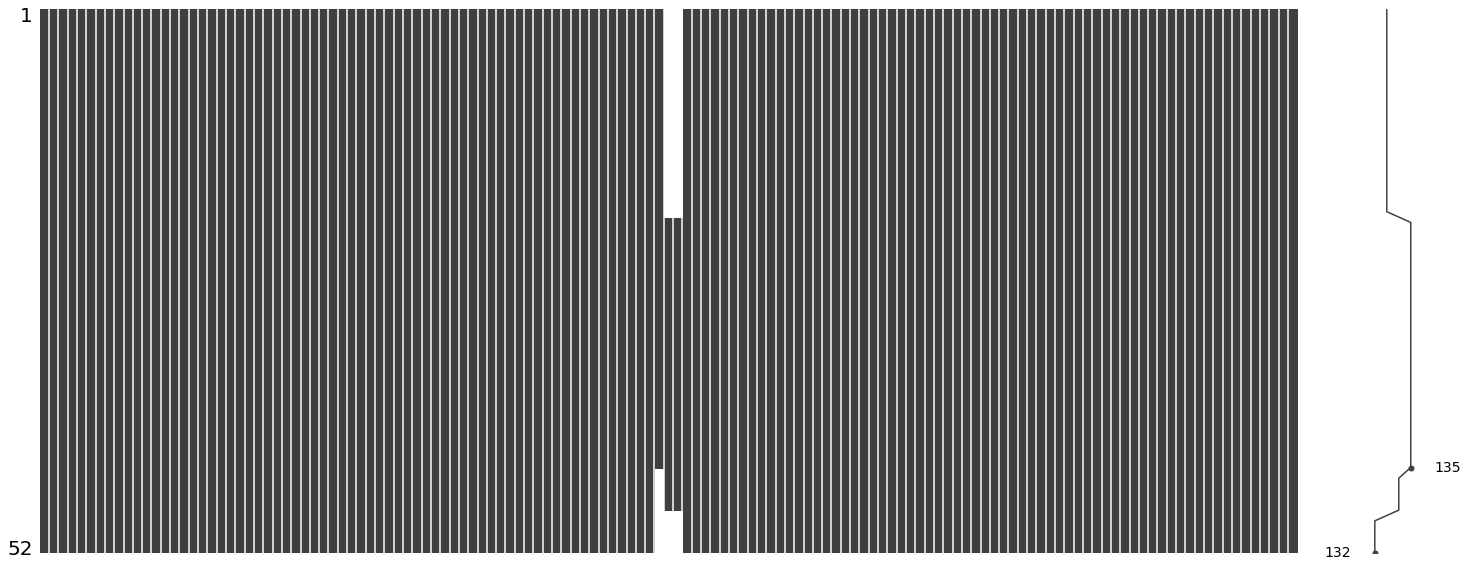

In [15]:
missingno.matrix(dataset_annual)

In [16]:
missing = describe_dataframe(dataset_annual, remove_zeros=True)
missing

,Column,Missing
0,MIO_EUR,15.3846
1,L_TOTAL,46.1538
2,UNL_TOTAL,46.1538


In [17]:
dataset_annual.head(15)

,year,nuts3,nuts2,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lst,lst_day,lst_night,monthly_lst_min,monthly_lst_max,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,lst_day_jan_mean,lst_day_feb_mean,lst_day_mar_mean,lst_day_apr_mean,lst_night_jan_mean,lst_night_feb_mean,lst_night_mar_mean,lst_night_apr_mean,rainfall,monthly_acc_prec,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL,mosq_pred,cases,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4
0,2010,καρδιτσας,θεσσαλιας,21.891852,39.318887,0.420966,0.149468,-0.245870,-0.149468,0.421255,0.151094,-0.244023,-0.151094,0.060333,0.060381,0.049164,0.060381,16.333333,20.000000,47.619048,810.536672,39.0,-3.0,42.0,15.500000,26.666667,26.666667,6.833333,1615.0,293.0,8.0,64.278800,626.0,120.0,120.0,586.0,15.879996,21.314623,10.455380,6.672834,26.707258,4.244922,5.776488,11.404881,11.743119,6.554321,9.567185,17.340627,17.776064,1.939336,1.975580,5.469135,5.710175,4.468128,134.972992,31.259106,61.908496,815.093641,17404.0,77291.0,28372.0,123067.0,16953.0,74300.0,35601.0,126854.0,3007.13,NaN,NaN,12274,0,4.637507,7.357251,11.420574,19.843123,0.383449,-0.200999,0.158689,-0.158689,0.392770,-0.205490,0.162573,-0.162573,0.073246,0.078471,0.085551,0.085551,4.637507,13.704011,24.138973,26.948072,0.425923,-0.266626,0.144752,-0.144752,0.430954,-0.261899,0.152391,-0.152391,0.065515,0.050747,0.065859,0.065859,4.637507,17.651788,28.281199,33.822259,0.451002,-0.296325,0.140514,-0.140514,0.454617,-0.291904,0.147006,-0.147006,0.062824,0.043300,0.062545,0.062545,4.637507,15.879996,28.281199,53.617530,0.420966,-0.245870,0.149468,-0.149468,0.421255,-0.244023,0.151094,-0.151094,0.060333,0.049164,0.060381,0.060381
1,2010,λαρισας,θεσσαλιας,22.405497,39.703383,0.383251,0.131294,-0.234086,-0.131294,0.349189,0.159533,-0.161820,-0.159533,0.049579,0.054829,0.040044,0.054829,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,16.780540,23.158666,10.396817,6.677373,28.496586,6.164893,6.682858,11.547467,11.962892,10.341826,10.872250,18.073805,18.637656,1.990602,2.485348,5.021128,5.288128,3.794415,114.687464,26.536070,52.833326,676.783218,23344.0,94158.0,25983.0,143485.0,22094.0,93589.0,31108.0,146791.0,4654.45,NaN,NaN,13764,9,6.031580,8.180938,11.597786,14.247724,0.381370,-0.065632,0.274440,-0.274440,0.252948,0.144640,0.325209,-0.325209,0.035171,0.043702,0.046088,0.046088,6.031580,14.416820,25.055456,22.029753,0.414290,-0.219758,0.176938,-0.176938,0.344860,-0.086125,0.221112,-0.221112,0.047171,0.039408,0.055167,0.055167,6.031580,18.649233,29.877821,30.789361,0.409306,-0.259786,0.137729,-0.137729,0.362424,-0.163518,0.173040,-0.173040,0.048964,0.037742,0.054949,0.054949,5.988202,16.780540,29.877821,45.532983,0.383251,-0.234086,0.131294,-0.131294,0.349189,-0.161820,0.159533,-0.159533,0.049579,0.040044,0.054829,0.054829
2,2010,μαγνησιας,θεσσαλιας,22.869212,39.281871,0.431217,0.182427,-0.222728,-0.182427,0.419909,0.181693,-0.211698,-0.181693,0.051276,0.052765,0.047902,0.052765,17.333333,19.000000,46.341463,808.571505,40.0,-

In [18]:
dataset_annual.cases.sum()

149

In [19]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'MIO_EUR']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['MIO_EUR']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

In [20]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'L_TOTAL']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['L_TOTAL']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

In [21]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'UNL_TOTAL']

temp_df = dataset_annual[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['UNL_TOTAL']

dataset_annual[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

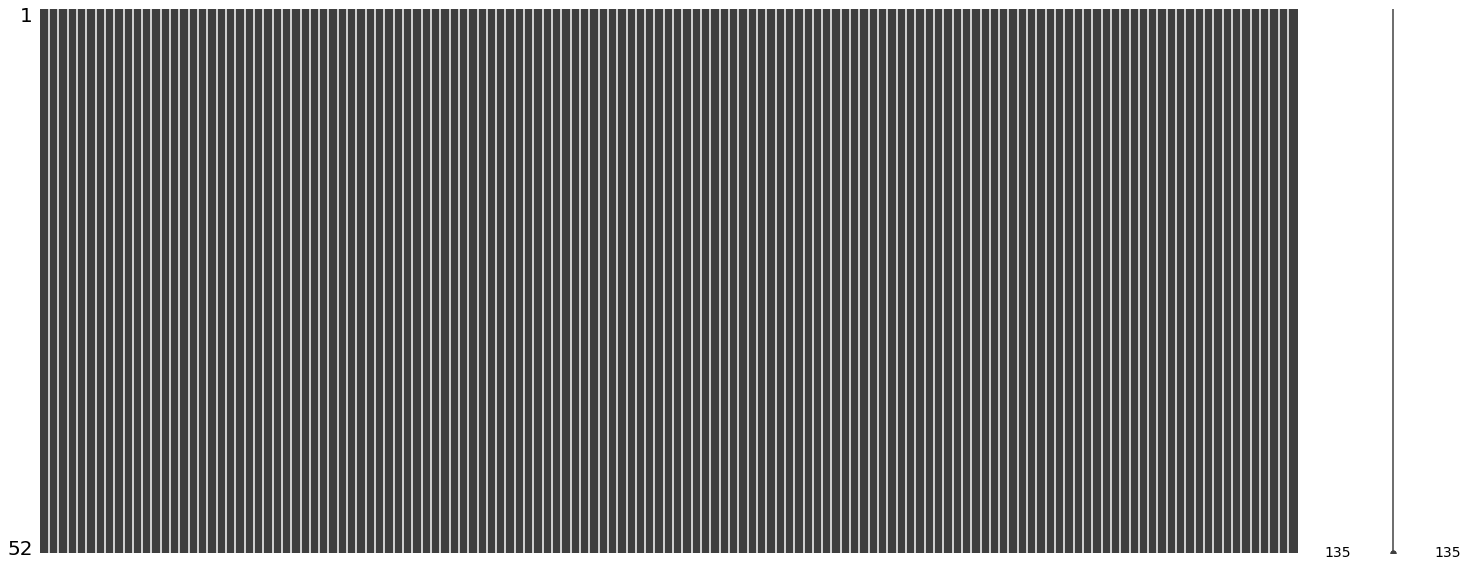

In [22]:
missingno.matrix(dataset_annual)

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\IPython\core\interactiveshell.py:3473: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if (await self.run_code(code, result,  async_=asy)):


<AxesSubplot:>

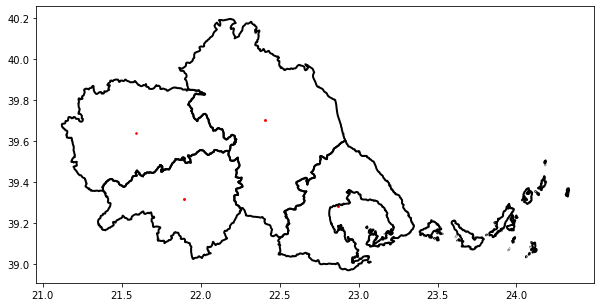

In [25]:
## Reading shapefiles from Greece
folder_path = "C:/Users/dimit/Documents/noa hoard/Greece Shapefiles"

greece_nuts3_gdf = gpd.read_file(f"{folder_path}/elladitsa_nomoi.shp",  encoding=dec)
greece_nuts2_gdf = gpd.read_file(f"{folder_path}/perifereies2.shp",  encoding=enc)

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)
greece_nuts2_gdf = greece_nuts2_gdf.to_crs(epsg=4326)

region = greece_nuts2_gdf.loc[greece_nuts2_gdf['PER'] == 'Π. ΘΕΣΣΑΛΙΑΣ'].copy()
nuts3_gdf = gpd.sjoin(greece_nuts3_gdf, region, how = 'inner', op='intersects')

wrong_list = ['Ν. ΠΙΕΡΙΑΣ', 'Ν. ΙΩΑΝΝΙΝΩΝ', 'Ν. ΕΥΡΥΤΑΝΙΑΣ', 'Ν. ΑΙΤΩΛΟΑΚΑΡΝΑΝΙΑΣ', 'Ν. ΚΟΖΑΝΗΣ', 'Ν. ΦΘΙΩΤΙΔΑΣ',
       'Ν. ΓΡΕΒΕΝΩΝ', 'Ν. ΑΡΤΑΣ']

nuts3_gdf = nuts3_gdf[~nuts3_gdf['NAME_GR'].isin(wrong_list)].copy()

nuts3_gdf.drop(columns=['PARENT', 'ESYE_ID', 'NAME_ENG', 'POP', 'EDRA', 'SHAPE_LENG', 'SHAPE_AREA', 'index_right', 'PER'], inplace = True)
nuts3_gdf.rename(columns={"NAME_GR": "nuts3"}, inplace = True)
nuts3_gdf.reset_index(drop = True, inplace = True)
process_greek(nuts3_gdf, 'nuts3')

nuts3_points = gpd.GeoDataFrame(dataset_annual[['nuts3']], geometry=gpd.points_from_xy(dataset_annual.x, dataset_annual.y))

ax = nuts3_points.head(7).plot(markersize=2.5, figsize=(10, 10), color='red')
nuts3_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [26]:
data_q1 = []
data_q2 = []
data_q3 = []
data_q4 = []

for year in years[1:]:
    for region in nuts3_units:

        df_preceding = dataset_annual.loc[(dataset_annual['year'] == year-1) & (dataset_annual['nuts3'] == region)]
        df_current = dataset_annual.loc[(dataset_annual['year'] == year) & (dataset_annual['nuts3'] == region)]

        data_q1.append({'year': year, 
                        'nuts3': region,
                        'nuts2': df_current.nuts2.iloc[0],
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q1': df_current.min_temp_q1.iloc[0],
                        'mean_temp_q1': df_current.mean_temp_q1.iloc[0],
                        'max_temp_q1': df_current.max_temp_q1.iloc[0],
                        'prec_q1': df_current.prec_q1.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q1': df_current.ndvi_q1.iloc[0],
                        'ndwi_q1': df_current.ndwi_q1.iloc[0],
                        'ndmi_q1': df_current.ndmi_q1.iloc[0],
                        'ndbi_q1': df_current.ndbi_q1.iloc[0],
                        'ndvi_mean_q1': df_current.ndvi_mean_q1.iloc[0],
                        'ndwi_mean_q1': df_current.ndwi_mean_q1.iloc[0],
                        'ndmi_mean_q1': df_current.ndmi_mean_q1.iloc[0],
                        'ndbi_mean_q1': df_current.ndbi_mean_q1.iloc[0],
                        'ndvi_std_q1': df_current.ndvi_std_q1.iloc[0],
                        'ndwi_std_q1': df_current.ndwi_std_q1.iloc[0],
                        'ndmi_std_q1': df_current.ndmi_std_q1.iloc[0],
                        'ndbi_std_q1': df_current.ndbi_std_q1.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q2.append({'year': year, 
                        'nuts3': region,
                        'nuts2': df_current.nuts2.iloc[0],
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q2': df_current.min_temp_q2.iloc[0],
                        'mean_temp_q2': df_current.mean_temp_q2.iloc[0],
                        'max_temp_q2': df_current.max_temp_q2.iloc[0],
                        'prec_q2': df_current.prec_q2.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q2': df_current.ndvi_q2.iloc[0],
                        'ndwi_q2': df_current.ndwi_q2.iloc[0],
                        'ndmi_q2': df_current.ndmi_q2.iloc[0],
                        'ndbi_q2': df_current.ndbi_q2.iloc[0],
                        'ndvi_mean_q2': df_current.ndvi_mean_q2.iloc[0],
                        'ndwi_mean_q2': df_current.ndwi_mean_q2.iloc[0],
                        'ndmi_mean_q2': df_current.ndmi_mean_q2.iloc[0],
                        'ndbi_mean_q2': df_current.ndbi_mean_q2.iloc[0],
                        'ndvi_std_q2': df_current.ndvi_std_q2.iloc[0],
                        'ndwi_std_q2': df_current.ndwi_std_q2.iloc[0],
                        'ndmi_std_q2': df_current.ndmi_std_q2.iloc[0],
                        'ndbi_std_q2': df_current.ndbi_std_q2.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q3.append({'year': year, 
                        'nuts3': region,
                        'nuts2': df_current.nuts2.iloc[0],
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q3': df_current.min_temp_q3.iloc[0],
                        'mean_temp_q3': df_current.mean_temp_q3.iloc[0],
                        'max_temp_q3': df_current.max_temp_q3.iloc[0],
                        'prec_q3': df_current.prec_q3.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q3': df_current.ndvi_q3.iloc[0],
                        'ndwi_q3': df_current.ndwi_q3.iloc[0],
                        'ndmi_q3': df_current.ndmi_q3.iloc[0],
                        'ndbi_q3': df_current.ndbi_q3.iloc[0],
                        'ndvi_mean_q3': df_current.ndvi_mean_q3.iloc[0],
                        'ndwi_mean_q3': df_current.ndwi_mean_q3.iloc[0],
                        'ndmi_mean_q3': df_current.ndmi_mean_q3.iloc[0],
                        'ndbi_mean_q3': df_current.ndbi_mean_q3.iloc[0],
                        'ndvi_std_q3': df_current.ndvi_std_q3.iloc[0],
                        'ndwi_std_q3': df_current.ndwi_std_q3.iloc[0],
                        'ndmi_std_q3': df_current.ndmi_std_q3.iloc[0],
                        'ndbi_std_q3': df_current.ndbi_std_q3.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
        data_q4.append({'year': year, 
                        'nuts3': region,
                        'nuts2': df_current.nuts2.iloc[0],
                        'x': df_current.x.iloc[0],
                        'y': df_current.y.iloc[0],
                        'min_temp_q4': df_current.min_temp_q4.iloc[0],
                        'mean_temp_q4': df_current.mean_temp_q4.iloc[0],
                        'max_temp_q4': df_current.max_temp_q4.iloc[0],
                        'prec_q4': df_current.prec_q4.iloc[0],
                        'bio1': df_preceding.bio1.iloc[0],
                        'bio2': df_preceding.bio2.iloc[0],
                        'bio3': df_preceding.bio3.iloc[0],
                        'bio4': df_preceding.bio4.iloc[0],
                        'bio5': df_preceding.bio5.iloc[0],
                        'bio6': df_preceding.bio6.iloc[0],
                        'bio7': df_preceding.bio7.iloc[0],
                        'bio8': df_preceding.bio8.iloc[0],
                        'bio9': df_preceding.bio9.iloc[0],
                        'bio10': df_preceding.bio10.iloc[0],
                        'bio11': df_preceding.bio11.iloc[0],
                        'bio12': df_preceding.bio12.iloc[0],
                        'bio13': df_preceding.bio13.iloc[0],
                        'bio14': df_preceding.bio14.iloc[0],
                        'bio15': df_preceding.bio15.iloc[0],
                        'bio16': df_preceding.bio16.iloc[0],
                        'bio17': df_preceding.bio17.iloc[0],
                        'bio18': df_preceding.bio18.iloc[0],
                        'bio19': df_preceding.bio19.iloc[0],
                        'ndvi_q4': df_current.ndvi_q4.iloc[0],
                        'ndwi_q4': df_current.ndwi_q4.iloc[0],
                        'ndmi_q4': df_current.ndmi_q4.iloc[0],
                        'ndbi_q4': df_current.ndbi_q4.iloc[0],
                        'ndvi_mean_q4': df_current.ndvi_mean_q4.iloc[0],
                        'ndwi_mean_q4': df_current.ndwi_mean_q4.iloc[0],
                        'ndmi_mean_q4': df_current.ndmi_mean_q4.iloc[0],
                        'ndbi_mean_q4': df_current.ndbi_mean_q4.iloc[0],
                        'ndvi_std_q4': df_current.ndvi_std_q4.iloc[0],
                        'ndwi_std_q4': df_current.ndwi_std_q4.iloc[0],
                        'ndmi_std_q4': df_current.ndmi_std_q4.iloc[0],
                        'ndbi_std_q4': df_current.ndbi_std_q4.iloc[0],
                        'M_TOTAL': df_preceding.M_TOTAL.iloc[0],
                        'M_Y_LT_15': df_preceding.M_Y_LT15.iloc[0],
                        'M_Y15-64': df_preceding['M_Y15-64'].iloc[0],
                        'M_Y_GE65': df_preceding.M_Y_GE65.iloc[0],
                        'F_TOTAL': df_preceding.F_TOTAL.iloc[0],
                        'F_Y_LT_15': df_preceding.F_Y_LT15.iloc[0],
                        'F_Y15-64': df_preceding['F_Y15-64'].iloc[0],
                        'F_Y_GE65': df_preceding.F_Y_GE65.iloc[0],
                        'MIO_EUR': df_preceding.MIO_EUR.iloc[0],
                        'L_TOTAL': df_preceding.L_TOTAL.iloc[0],
                        'UNL_TOTAL': df_preceding.UNL_TOTAL.iloc[0],
                        'culex_pipiens': df_preceding.mosq_pred.iloc[0],
                        'WNV_cases': df_current.cases.iloc[0]
                        })
        
df_q1 = pd.DataFrame(data_q1)
df_q2 = pd.DataFrame(data_q2)   
df_q3 = pd.DataFrame(data_q3)   
df_q4 = pd.DataFrame(data_q4)   

In [27]:
df_q1

,year,nuts3,nuts2,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,καρδιτσας,θεσσαλιας,21.891852,39.318887,4.157309,6.551922,8.922110,13.874227,16.333333,20.000000,47.619048,810.536672,39.0,-3.0,42.0,15.500000,26.666667,26.666667,6.833333,1615.0,293.0,8.0,64.278800,626.0,120.0,120.0,586.0,0.170425,0.316432,0.439041,-0.439041,0.178578,0.268765,0.405197,-0.405197,0.048249,0.093092,0.062218,0.062218,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10971.4,11056.4,12274,9
1,2011,λαρισας,θεσσαλιας,22.405497,39.703383,4.875334,7.634680,10.206574,10.048595,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,0.294055,0.019309,0.273389,-0.273389,0.299809,0.018538,0.280083,-0.280083,0.042559,0.047435,0.047199,0.047199,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,7470.2,7618.8,13764,15
2,2011,μαγνησιας,θεσσαλιας,22.869212,39.281871,5.750763,8.038521,10.445737,15.117940,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,0.337567,0.009852,0.289970,-0.289970,0.329326,0.020087,0.296028,-0.296028,0.046129,0.075248,0.053855,0.053855,101047.0,15287.0,68105.0,17655.0,105732.0,14898.0,67890.0,22944.0,3102.990,7159.4,7339.6,8002,1
3,2011,τρικαλων,θεσσαλιας,21.591863,39.641569,3.338259,5.519229,7.835045,14.839091,14.458333,19.250000,45.833333,792.423880,38.0,-4.0,42.0,14.333333,24.500000,24.500000,5.166667,2288.0,390.0,10.0,63.081352,951.0,159.0,159.0,787.0,0.270235,0.062354,0.295512,-0.295512,0.272258,0.053011,0.287726,-0.287726,0.051389,0.082681,0.061490,0.061490,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10971.4,11056.4,19420,5
4,2012,καρδιτσας,θεσσαλιας,21.891852,39.318887,1.880089,5.521976,11.388065,13.401087,14.750000,19.333333,49.572650,842.749828,36.0,-3.0,39.0,4.666667,25.166667,25.166667,4.666667,1120.0,180.0,1.0,65.198982,426.0,76.0,76.0,426.0,0.176579,0.113414,0.248189,-0.248189,0.169458,0.129859,0.257065,-0.257065,0.052999,0.089317,0.066027,0.066027,123287.0,17312.0,77199.0,28776.0,126475.0,16778.0,73914.0,35783.0,2698.510,10971.4,11056.4,15782,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,2021,τρικαλων,θεσσαλιας,21.591863,39.641569,3.233074,6.347131,8.178302,26.777960,15.208333,19.250000,46.951220,797.854604,36.0,-5.0,41.0,10.000000,22.500000,25.166667,5.833333,1392.0,281.0,41.0,57.405688,475.0,224.0,252.0,416.0,0.323949,-0.282438,0.166935,-0.166935,0.307240,-0.268460,0.185147,-0.185147,0.059562,0.053104,0.072855,0.072855,114955.0,14936.0,69399.0,30620.0,117475.0,14081.0,67437.0,35957.0,2452.450,8644.0,7197.0,25813,0
44,2022,καρδιτσας,θεσσαλιας,21.891852,39.318887,4.723939,6.034817,6.772590,11.826364,17.208333,19.416667,47.357724,844.085932,39.0,-2.0,41.0,8.500000,24.833333,27.000000,7.000000,1611.0,399.0,29.0,84.079448,851.0,119.0,120.0,776.0,0.318466,-0.266173,0.153806,-0.153806,0.309912,-0.260987,0.159924,-0.159924,0.066105,0.061733,0.073456,0.073456,113824.0,14610.0,68583.0,30631.0,116276.0,13766.0,66633.0,35877.0,2753.426,6070.0,6292.0,8685,0
45,2022,λαρισας,θεσσαλιας,22.405497,39.703383,5.041239,6.584105,7.409691,12.675841,18.208333,22.250000,47.340426,877.097054,44.0,-3.0,47.0,9.833333,25.833333,28.333333,7.166667,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.382134,-0.332549,0.126803,-0.126803,0.366238,-0.319081,0.

In [28]:
df_q2

,year,nuts3,nuts2,x,y,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,καρδιτσας,θεσσαλιας,21.891852,39.318887,4.157309,12.597298,23.708046,20.873508,16.333333,20.000000,47.619048,810.536672,39.0,-3.0,42.0,15.500000,26.666667,26.666667,6.833333,1615.0,293.0,8.0,64.278800,626.0,120.0,120.0,586.0,0.297577,0.040005,0.300550,-0.300550,0.302549,0.020340,0.288073,-0.288073,0.055185,0.070571,0.060652,0.060652,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10971.4,11056.4,12274,9
1,2011,λαρισας,θεσσαλιας,22.405497,39.703383,4.875334,13.453741,24.974145,17.113235,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,0.358509,-0.115561,0.214682,-0.214682,0.360713,-0.113695,0.219722,-0.219722,0.045213,0.041865,0.050537,0.050537,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,7470.2,7618.8,13764,15
2,2011,μαγνησιας,θεσσαλιας,22.869212,39.281871,5.750763,13.303240,23.938267,23.164064,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,0.387653,-0.103838,0.241372,-0.241372,0.381755,-0.097753,0.244128,-0.244128,0.045229,0.056461,0.048786,0.048786,101047.0,15287.0,68105.0,17655.0,105732.0,14898.0,67890.0,22944.0,3102.990,7159.4,7339.6,8002,1
3,2011,τρικαλων,θεσσαλιας,21.591863,39.641569,3.338259,11.034262,20.982477,23.391027,14.458333,19.250000,45.833333,792.423880,38.0,-4.0,42.0,14.333333,24.500000,24.500000,5.166667,2288.0,390.0,10.0,63.081352,951.0,159.0,159.0,787.0,0.380453,-0.095692,0.248194,-0.248194,0.378295,-0.093158,0.248119,-0.248119,0.049552,0.062374,0.056396,0.056396,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10971.4,11056.4,19420,5
4,2012,καρδιτσας,θεσσαλιας,21.891852,39.318887,1.880089,13.154902,26.875718,24.109457,14.750000,19.333333,49.572650,842.749828,36.0,-3.0,39.0,4.666667,25.166667,25.166667,4.666667,1120.0,180.0,1.0,65.198982,426.0,76.0,76.0,426.0,0.304894,-0.084515,0.193510,-0.193510,0.299968,-0.076068,0.196760,-0.196760,0.060372,0.066171,0.065527,0.065527,123287.0,17312.0,77199.0,28776.0,126475.0,16778.0,73914.0,35783.0,2698.510,10971.4,11056.4,15782,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,2021,τρικαλων,θεσσαλιας,21.591863,39.641569,3.233074,12.223167,22.169476,33.101958,15.208333,19.250000,46.951220,797.854604,36.0,-5.0,41.0,10.000000,22.500000,25.166667,5.833333,1392.0,281.0,41.0,57.405688,475.0,224.0,252.0,416.0,0.400361,-0.353239,0.156409,-0.156409,0.386191,-0.341230,0.167736,-0.167736,0.060638,0.048988,0.065624,0.065624,114955.0,14936.0,69399.0,30620.0,117475.0,14081.0,67437.0,35957.0,2452.450,8644.0,7197.0,25813,0
44,2022,καρδιτσας,θεσσαλιας,21.891852,39.318887,4.723939,13.651757,26.253625,22.996472,17.208333,19.416667,47.357724,844.085932,39.0,-2.0,41.0,8.500000,24.833333,27.000000,7.000000,1611.0,399.0,29.0,84.079448,851.0,119.0,120.0,776.0,0.380247,-0.331683,0.138959,-0.138959,0.372733,-0.325761,0.144235,-0.144235,0.067236,0.056390,0.067963,0.067963,113824.0,14610.0,68583.0,30631.0,116276.0,13766.0,66633.0,35877.0,2753.426,6070.0,6292.0,8685,0
45,2022,λαρισας,θεσσαλιας,22.405497,39.703383,5.041239,14.228542,27.536030,22.933007,18.208333,22.250000,47.340426,877.097054,44.0,-3.0,47.0,9.833333,25.833333,28.333333,7.166667,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.404737,-0.363558,0.122827,-0.122827,

In [29]:
df_q3

,year,nuts3,nuts2,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,καρδιτσας,θεσσαλιας,21.891852,39.318887,4.157309,16.893831,27.190522,24.555063,16.333333,20.000000,47.619048,810.536672,39.0,-3.0,42.0,15.500000,26.666667,26.666667,6.833333,1615.0,293.0,8.0,64.278800,626.0,120.0,120.0,586.0,0.358070,-0.078761,0.253836,-0.253836,0.360943,-0.091596,0.245221,-0.245221,0.060191,0.061722,0.063847,0.063847,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10971.4,11056.4,12274,9
1,2011,λαρισας,θεσσαλιας,22.405497,39.703383,4.875334,18.109422,29.505567,22.503622,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,0.362258,-0.193909,0.155312,-0.155312,0.362993,-0.192573,0.158199,-0.158199,0.052767,0.039836,0.057991,0.057991,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,7470.2,7618.8,13764,15
2,2011,μαγνησιας,θεσσαλιας,22.869212,39.281871,5.750763,17.630415,27.951788,27.447041,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,0.406250,-0.171623,0.207952,-0.207952,0.401349,-0.167704,0.209458,-0.209458,0.050077,0.049983,0.052770,0.052770,101047.0,15287.0,68105.0,17655.0,105732.0,14898.0,67890.0,22944.0,3102.990,7159.4,7339.6,8002,1
3,2011,τρικαλων,θεσσαλιας,21.591863,39.641569,3.338259,15.475861,25.456094,27.804143,14.458333,19.250000,45.833333,792.423880,38.0,-4.0,42.0,14.333333,24.500000,24.500000,5.166667,2288.0,390.0,10.0,63.081352,951.0,159.0,159.0,787.0,0.415328,-0.170545,0.217009,-0.217009,0.413086,-0.165776,0.218757,-0.218757,0.052277,0.056111,0.059280,0.059280,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10971.4,11056.4,19420,5
4,2012,καρδιτσας,θεσσαλιας,21.891852,39.318887,1.880089,17.614608,28.990401,28.665795,14.750000,19.333333,49.572650,842.749828,36.0,-3.0,39.0,4.666667,25.166667,25.166667,4.666667,1120.0,180.0,1.0,65.198982,426.0,76.0,76.0,426.0,0.362046,-0.164225,0.180610,-0.180610,0.359827,-0.159232,0.183297,-0.183297,0.064638,0.056389,0.067077,0.067077,123287.0,17312.0,77199.0,28776.0,126475.0,16778.0,73914.0,35783.0,2698.510,10971.4,11056.4,15782,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,2021,τρικαλων,θεσσαλιας,21.591863,39.641569,3.233074,16.686405,27.415908,38.302058,15.208333,19.250000,46.951220,797.854604,36.0,-5.0,41.0,10.000000,22.500000,25.166667,5.833333,1392.0,281.0,41.0,57.405688,475.0,224.0,252.0,416.0,0.425348,-0.381221,0.139779,-0.139779,0.412579,-0.370369,0.146862,-0.146862,0.064263,0.048779,0.067614,0.067614,114955.0,14936.0,69399.0,30620.0,117475.0,14081.0,67437.0,35957.0,2452.450,8644.0,7197.0,25813,0
44,2022,καρδιτσας,θεσσαλιας,21.891852,39.318887,4.723939,17.306703,26.253625,29.866904,17.208333,19.416667,47.357724,844.085932,39.0,-2.0,41.0,8.500000,24.833333,27.000000,7.000000,1611.0,399.0,29.0,84.079448,851.0,119.0,120.0,776.0,0.426924,-0.373039,0.144117,-0.144117,0.420692,-0.368130,0.146354,-0.146354,0.068284,0.055166,0.069141,0.069141,113824.0,14610.0,68583.0,30631.0,116276.0,13766.0,66633.0,35877.0,2753.426,6070.0,6292.0,8685,0
45,2022,λαρισας,θεσσαλιας,22.405497,39.703383,5.041239,18.381475,28.484998,33.850996,18.208333,22.250000,47.340426,877.097054,44.0,-3.0,47.0,9.833333,25.833333,28.333333,7.166667,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.398211,-0.365509,0.087651,-0.08765

In [30]:
df_q4

,year,nuts3,nuts2,x,y,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,καρδιτσας,θεσσαλιας,21.891852,39.318887,4.157309,15.081144,27.190522,37.014938,16.333333,20.000000,47.619048,810.536672,39.0,-3.0,42.0,15.500000,26.666667,26.666667,6.833333,1615.0,293.0,8.0,64.278800,626.0,120.0,120.0,586.0,0.345450,-0.105802,0.210994,-0.210994,0.347915,-0.117999,0.203398,-0.203398,0.061548,0.067521,0.065987,0.065987,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10971.4,11056.4,12274,9
1,2011,λαρισας,θεσσαλιας,22.405497,39.703383,4.875334,16.233171,29.505567,30.736684,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,0.339338,-0.210817,0.113893,-0.113893,0.338700,-0.209326,0.115652,-0.115652,0.052172,0.045425,0.059106,0.059106,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,7470.2,7618.8,13764,15
2,2011,μαγνησιας,θεσσαλιας,22.869212,39.281871,5.750763,15.989930,27.951788,35.960870,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,0.389605,-0.164112,0.194131,-0.194131,0.384087,-0.159440,0.195163,-0.195163,0.051306,0.056083,0.055047,0.055047,101047.0,15287.0,68105.0,17655.0,105732.0,14898.0,67890.0,22944.0,3102.990,7159.4,7339.6,8002,1
3,2011,τρικαλων,θεσσαλιας,21.591863,39.641569,3.338259,13.728888,25.456094,42.934600,14.458333,19.250000,45.833333,792.423880,38.0,-4.0,42.0,14.333333,24.500000,24.500000,5.166667,2288.0,390.0,10.0,63.081352,951.0,159.0,159.0,787.0,0.398493,-0.165625,0.202041,-0.202041,0.395547,-0.159740,0.204501,-0.204501,0.052980,0.063358,0.062555,0.062555,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10971.4,11056.4,19420,5
4,2012,καρδιτσας,θεσσαλιας,21.891852,39.318887,1.880089,16.014209,28.990401,49.697512,14.750000,19.333333,49.572650,842.749828,36.0,-3.0,39.0,4.666667,25.166667,25.166667,4.666667,1120.0,180.0,1.0,65.198982,426.0,76.0,76.0,426.0,0.368300,-0.161815,0.179927,-0.179927,0.369247,-0.157655,0.184619,-0.184619,0.066064,0.064934,0.068040,0.068040,123287.0,17312.0,77199.0,28776.0,126475.0,16778.0,73914.0,35783.0,2698.510,10971.4,11056.4,15782,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43,2021,τρικαλων,θεσσαλιας,21.591863,39.641569,3.233074,17.348927,27.415908,62.515466,15.208333,19.250000,46.951220,797.854604,36.0,-5.0,41.0,10.000000,22.500000,25.166667,5.833333,1392.0,281.0,41.0,57.405688,475.0,224.0,252.0,416.0,0.430790,-0.387534,0.134212,-0.134212,0.390732,-0.354384,0.156566,-0.156566,0.059495,0.044198,0.063390,0.063390,114955.0,14936.0,69399.0,30620.0,117475.0,14081.0,67437.0,35957.0,2452.450,8644.0,7197.0,25813,0
44,2022,καρδιτσας,θεσσαλιας,21.891852,39.318887,4.723939,16.126316,26.253625,32.236783,17.208333,19.416667,47.357724,844.085932,39.0,-2.0,41.0,8.500000,24.833333,27.000000,7.000000,1611.0,399.0,29.0,84.079448,851.0,119.0,120.0,776.0,0.404962,-0.351909,0.123523,-0.123523,0.396033,-0.344564,0.124165,-0.124165,0.065676,0.054569,0.065863,0.065863,113824.0,14610.0,68583.0,30631.0,116276.0,13766.0,66633.0,35877.0,2753.426,6070.0,6292.0,8685,0
45,2022,λαρισας,θεσσαλιας,22.405497,39.703383,5.041239,17.149741,28.484998,36.243313,18.208333,22.250000,47.340426,877.097054,44.0,-3.0,47.0,9.833333,25.833333,28.333333,7.166667,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.370733,-0.339116,0.064168,-0.06416

In [31]:
print(df_q1.WNV_cases.sum())
print(df_q2.WNV_cases.sum())
print(df_q3.WNV_cases.sum())
print(df_q4.WNV_cases.sum())

140
140
140
140


In [32]:
df_q1 = convert_multiple_cases(df_q1, target_col='WNV_cases')
df_q2 = convert_multiple_cases(df_q2, target_col='WNV_cases')
df_q3 = convert_multiple_cases(df_q3, target_col='WNV_cases')
df_q4 = convert_multiple_cases(df_q4, target_col='WNV_cases')

In [33]:
print(df_q1.WNV_cases.sum())
print(df_q2.WNV_cases.sum())
print(df_q3.WNV_cases.sum())
print(df_q4.WNV_cases.sum())

140
140
140
140


In [34]:
df_q1

,year,nuts3,nuts2,x,y,min_temp_q1,mean_temp_q1,max_temp_q1,prec_q1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q1,ndwi_q1,ndmi_q1,ndbi_q1,ndvi_mean_q1,ndwi_mean_q1,ndmi_mean_q1,ndbi_mean_q1,ndvi_std_q1,ndwi_std_q1,ndmi_std_q1,ndbi_std_q1,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,καρδιτσας,θεσσαλιας,21.891852,39.318887,4.157309,6.551922,8.922110,13.874227,16.333333,20.000000,47.619048,810.536672,39.0,-3.0,42.0,15.500000,26.666667,26.666667,6.833333,1615.0,293.0,8.0,64.278800,626.0,120.0,120.0,586.0,0.170425,0.316432,0.439041,-0.439041,0.178578,0.268765,0.405197,-0.405197,0.048249,0.093092,0.062218,0.062218,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10971.4,11056.4,12274,1
1,2011,λαρισας,θεσσαλιας,22.405497,39.703383,4.875334,7.634680,10.206574,10.048595,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,0.294055,0.019309,0.273389,-0.273389,0.299809,0.018538,0.280083,-0.280083,0.042559,0.047435,0.047199,0.047199,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,7470.2,7618.8,13764,1
2,2011,μαγνησιας,θεσσαλιας,22.869212,39.281871,5.750763,8.038521,10.445737,15.117940,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,0.337567,0.009852,0.289970,-0.289970,0.329326,0.020087,0.296028,-0.296028,0.046129,0.075248,0.053855,0.053855,101047.0,15287.0,68105.0,17655.0,105732.0,14898.0,67890.0,22944.0,3102.990,7159.4,7339.6,8002,1
3,2011,τρικαλων,θεσσαλιας,21.591863,39.641569,3.338259,5.519229,7.835045,14.839091,14.458333,19.250000,45.833333,792.423880,38.0,-4.0,42.0,14.333333,24.500000,24.500000,5.166667,2288.0,390.0,10.0,63.081352,951.0,159.0,159.0,787.0,0.270235,0.062354,0.295512,-0.295512,0.272258,0.053011,0.287726,-0.287726,0.051389,0.082681,0.061490,0.061490,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10971.4,11056.4,19420,1
4,2012,καρδιτσας,θεσσαλιας,21.891852,39.318887,1.880089,5.521976,11.388065,13.401087,14.750000,19.333333,49.572650,842.749828,36.0,-3.0,39.0,4.666667,25.166667,25.166667,4.666667,1120.0,180.0,1.0,65.198982,426.0,76.0,76.0,426.0,0.176579,0.113414,0.248189,-0.248189,0.169458,0.129859,0.257065,-0.257065,0.052999,0.089317,0.066027,0.066027,123287.0,17312.0,77199.0,28776.0,126475.0,16778.0,73914.0,35783.0,2698.510,10971.4,11056.4,15782,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,2022,λαρισας,θεσσαλιας,22.405497,39.703383,5.041239,6.584105,7.409691,12.675841,18.208333,22.250000,47.340426,877.097054,44.0,-3.0,47.0,9.833333,25.833333,28.333333,7.166667,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.382134,-0.332549,0.126803,-0.126803,0.366238,-0.319081,0.127453,-0.127453,0.060245,0.050407,0.065043,0.065043,135011.0,21009.0,84294.0,29708.0,143493.0,19676.0,88295.0,35522.0,3042.892,2621.0,2977.0,12896,1
171,2022,λαρισας,θεσσαλιας,22.405497,39.703383,5.041239,6.584105,7.409691,12.675841,18.208333,22.250000,47.340426,877.097054,44.0,-3.0,47.0,9.833333,25.833333,28.333333,7.166667,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.382134,-0.332549,0.126803,-0.126803,0.366238,-0.319081,0.127453,-0.127453,0.060245,0.050407,0.065043,0.065043,135011.0,21009.0,84294.0,29708.0,143493.0,19676.0,88295.0,35522.0,3042.892,2621.0,2977.0,12896,1
172,2022,λαρισας,θεσσαλιας,22.405497,39.703383,5.041239,6.584105,7.409691,12.675841,18.208333,22.250000,47.340426,877.097054,44.0,-3.0,47.0,9.833333,25.833333,28.333333,7.166667,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.382134,-0.332549,0.126803,-0.126803,0.366238,-0.319081,0.1

In [35]:
df_q2

,year,nuts3,nuts2,x,y,min_temp_q2,mean_temp_q2,max_temp_q2,prec_q2,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q2,ndwi_q2,ndmi_q2,ndbi_q2,ndvi_mean_q2,ndwi_mean_q2,ndmi_mean_q2,ndbi_mean_q2,ndvi_std_q2,ndwi_std_q2,ndmi_std_q2,ndbi_std_q2,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,καρδιτσας,θεσσαλιας,21.891852,39.318887,4.157309,12.597298,23.708046,20.873508,16.333333,20.000000,47.619048,810.536672,39.0,-3.0,42.0,15.500000,26.666667,26.666667,6.833333,1615.0,293.0,8.0,64.278800,626.0,120.0,120.0,586.0,0.297577,0.040005,0.300550,-0.300550,0.302549,0.020340,0.288073,-0.288073,0.055185,0.070571,0.060652,0.060652,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10971.4,11056.4,12274,1
1,2011,λαρισας,θεσσαλιας,22.405497,39.703383,4.875334,13.453741,24.974145,17.113235,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,0.358509,-0.115561,0.214682,-0.214682,0.360713,-0.113695,0.219722,-0.219722,0.045213,0.041865,0.050537,0.050537,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,7470.2,7618.8,13764,1
2,2011,μαγνησιας,θεσσαλιας,22.869212,39.281871,5.750763,13.303240,23.938267,23.164064,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,0.387653,-0.103838,0.241372,-0.241372,0.381755,-0.097753,0.244128,-0.244128,0.045229,0.056461,0.048786,0.048786,101047.0,15287.0,68105.0,17655.0,105732.0,14898.0,67890.0,22944.0,3102.990,7159.4,7339.6,8002,1
3,2011,τρικαλων,θεσσαλιας,21.591863,39.641569,3.338259,11.034262,20.982477,23.391027,14.458333,19.250000,45.833333,792.423880,38.0,-4.0,42.0,14.333333,24.500000,24.500000,5.166667,2288.0,390.0,10.0,63.081352,951.0,159.0,159.0,787.0,0.380453,-0.095692,0.248194,-0.248194,0.378295,-0.093158,0.248119,-0.248119,0.049552,0.062374,0.056396,0.056396,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10971.4,11056.4,19420,1
4,2012,καρδιτσας,θεσσαλιας,21.891852,39.318887,1.880089,13.154902,26.875718,24.109457,14.750000,19.333333,49.572650,842.749828,36.0,-3.0,39.0,4.666667,25.166667,25.166667,4.666667,1120.0,180.0,1.0,65.198982,426.0,76.0,76.0,426.0,0.304894,-0.084515,0.193510,-0.193510,0.299968,-0.076068,0.196760,-0.196760,0.060372,0.066171,0.065527,0.065527,123287.0,17312.0,77199.0,28776.0,126475.0,16778.0,73914.0,35783.0,2698.510,10971.4,11056.4,15782,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,2022,λαρισας,θεσσαλιας,22.405497,39.703383,5.041239,14.228542,27.536030,22.933007,18.208333,22.250000,47.340426,877.097054,44.0,-3.0,47.0,9.833333,25.833333,28.333333,7.166667,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.404737,-0.363558,0.122827,-0.122827,0.391423,-0.351654,0.125106,-0.125106,0.059276,0.046457,0.063936,0.063936,135011.0,21009.0,84294.0,29708.0,143493.0,19676.0,88295.0,35522.0,3042.892,2621.0,2977.0,12896,1
171,2022,λαρισας,θεσσαλιας,22.405497,39.703383,5.041239,14.228542,27.536030,22.933007,18.208333,22.250000,47.340426,877.097054,44.0,-3.0,47.0,9.833333,25.833333,28.333333,7.166667,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.404737,-0.363558,0.122827,-0.122827,0.391423,-0.351654,0.125106,-0.125106,0.059276,0.046457,0.063936,0.063936,135011.0,21009.0,84294.0,29708.0,143493.0,19676.0,88295.0,35522.0,3042.892,2621.0,2977.0,12896,1
172,2022,λαρισας,θεσσαλιας,22.405497,39.703383,5.041239,14.228542,27.536030,22.933007,18.208333,22.250000,47.340426,877.097054,44.0,-3.0,47.0,9.833333,25.833333,28.333333,7.166667,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.404737,-0.363558,0.122827,-0.122827,0

In [36]:
df_q3

,year,nuts3,nuts2,x,y,min_temp_q3,mean_temp_q3,max_temp_q3,prec_q3,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q3,ndwi_q3,ndmi_q3,ndbi_q3,ndvi_mean_q3,ndwi_mean_q3,ndmi_mean_q3,ndbi_mean_q3,ndvi_std_q3,ndwi_std_q3,ndmi_std_q3,ndbi_std_q3,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,καρδιτσας,θεσσαλιας,21.891852,39.318887,4.157309,16.893831,27.190522,24.555063,16.333333,20.000000,47.619048,810.536672,39.0,-3.0,42.0,15.500000,26.666667,26.666667,6.833333,1615.0,293.0,8.0,64.278800,626.0,120.0,120.0,586.0,0.358070,-0.078761,0.253836,-0.253836,0.360943,-0.091596,0.245221,-0.245221,0.060191,0.061722,0.063847,0.063847,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10971.4,11056.4,12274,1
1,2011,λαρισας,θεσσαλιας,22.405497,39.703383,4.875334,18.109422,29.505567,22.503622,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,0.362258,-0.193909,0.155312,-0.155312,0.362993,-0.192573,0.158199,-0.158199,0.052767,0.039836,0.057991,0.057991,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,7470.2,7618.8,13764,1
2,2011,μαγνησιας,θεσσαλιας,22.869212,39.281871,5.750763,17.630415,27.951788,27.447041,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,0.406250,-0.171623,0.207952,-0.207952,0.401349,-0.167704,0.209458,-0.209458,0.050077,0.049983,0.052770,0.052770,101047.0,15287.0,68105.0,17655.0,105732.0,14898.0,67890.0,22944.0,3102.990,7159.4,7339.6,8002,1
3,2011,τρικαλων,θεσσαλιας,21.591863,39.641569,3.338259,15.475861,25.456094,27.804143,14.458333,19.250000,45.833333,792.423880,38.0,-4.0,42.0,14.333333,24.500000,24.500000,5.166667,2288.0,390.0,10.0,63.081352,951.0,159.0,159.0,787.0,0.415328,-0.170545,0.217009,-0.217009,0.413086,-0.165776,0.218757,-0.218757,0.052277,0.056111,0.059280,0.059280,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10971.4,11056.4,19420,1
4,2012,καρδιτσας,θεσσαλιας,21.891852,39.318887,1.880089,17.614608,28.990401,28.665795,14.750000,19.333333,49.572650,842.749828,36.0,-3.0,39.0,4.666667,25.166667,25.166667,4.666667,1120.0,180.0,1.0,65.198982,426.0,76.0,76.0,426.0,0.362046,-0.164225,0.180610,-0.180610,0.359827,-0.159232,0.183297,-0.183297,0.064638,0.056389,0.067077,0.067077,123287.0,17312.0,77199.0,28776.0,126475.0,16778.0,73914.0,35783.0,2698.510,10971.4,11056.4,15782,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,2022,λαρισας,θεσσαλιας,22.405497,39.703383,5.041239,18.381475,28.484998,33.850996,18.208333,22.250000,47.340426,877.097054,44.0,-3.0,47.0,9.833333,25.833333,28.333333,7.166667,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.398211,-0.365509,0.087651,-0.087651,0.388426,-0.356267,0.091034,-0.091034,0.060048,0.045394,0.064120,0.064120,135011.0,21009.0,84294.0,29708.0,143493.0,19676.0,88295.0,35522.0,3042.892,2621.0,2977.0,12896,1
171,2022,λαρισας,θεσσαλιας,22.405497,39.703383,5.041239,18.381475,28.484998,33.850996,18.208333,22.250000,47.340426,877.097054,44.0,-3.0,47.0,9.833333,25.833333,28.333333,7.166667,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.398211,-0.365509,0.087651,-0.087651,0.388426,-0.356267,0.091034,-0.091034,0.060048,0.045394,0.064120,0.064120,135011.0,21009.0,84294.0,29708.0,143493.0,19676.0,88295.0,35522.0,3042.892,2621.0,2977.0,12896,1
172,2022,λαρισας,θεσσαλιας,22.405497,39.703383,5.041239,18.381475,28.484998,33.850996,18.208333,22.250000,47.340426,877.097054,44.0,-3.0,47.0,9.833333,25.833333,28.333333,7.166667,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.398211,-0.365509,0.087651,-0.087651

In [37]:
df_q4

,year,nuts3,nuts2,x,y,min_temp_q4,mean_temp_q4,max_temp_q4,prec_q4,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,ndvi_q4,ndwi_q4,ndmi_q4,ndbi_q4,ndvi_mean_q4,ndwi_mean_q4,ndmi_mean_q4,ndbi_mean_q4,ndvi_std_q4,ndwi_std_q4,ndmi_std_q4,ndbi_std_q4,M_TOTAL,M_Y_LT_15,M_Y15-64,M_Y_GE65,F_TOTAL,F_Y_LT_15,F_Y15-64,F_Y_GE65,MIO_EUR,L_TOTAL,UNL_TOTAL,culex_pipiens,WNV_cases
0,2011,καρδιτσας,θεσσαλιας,21.891852,39.318887,4.157309,15.081144,27.190522,37.014938,16.333333,20.000000,47.619048,810.536672,39.0,-3.0,42.0,15.500000,26.666667,26.666667,6.833333,1615.0,293.0,8.0,64.278800,626.0,120.0,120.0,586.0,0.345450,-0.105802,0.210994,-0.210994,0.347915,-0.117999,0.203398,-0.203398,0.061548,0.067521,0.065987,0.065987,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10971.4,11056.4,12274,1
1,2011,λαρισας,θεσσαλιας,22.405497,39.703383,4.875334,16.233171,29.505567,30.736684,17.291667,21.583333,47.962963,881.233210,42.0,-3.0,45.0,17.166667,28.333333,28.333333,6.666667,1371.0,275.0,22.0,62.577013,550.0,158.0,158.0,378.0,0.339338,-0.210817,0.113893,-0.113893,0.338700,-0.209326,0.115652,-0.115652,0.052172,0.045425,0.059106,0.059106,143485.0,23344.0,94158.0,25983.0,146791.0,22094.0,93589.0,31108.0,4654.450,7470.2,7618.8,13764,1
2,2011,μαγνησιας,θεσσαλιας,22.869212,39.281871,5.750763,15.989930,27.951788,35.960870,17.333333,19.000000,46.341463,808.571505,40.0,-1.0,41.0,17.000000,27.666667,27.666667,7.833333,1243.0,266.0,10.0,67.794059,476.0,129.0,129.0,391.0,0.389605,-0.164112,0.194131,-0.194131,0.384087,-0.159440,0.195163,-0.195163,0.051306,0.056083,0.055047,0.055047,101047.0,15287.0,68105.0,17655.0,105732.0,14898.0,67890.0,22944.0,3102.990,7159.4,7339.6,8002,1
3,2011,τρικαλων,θεσσαλιας,21.591863,39.641569,3.338259,13.728888,25.456094,42.934600,14.458333,19.250000,45.833333,792.423880,38.0,-4.0,42.0,14.333333,24.500000,24.500000,5.166667,2288.0,390.0,10.0,63.081352,951.0,159.0,159.0,787.0,0.398493,-0.165625,0.202041,-0.202041,0.395547,-0.159740,0.204501,-0.204501,0.052980,0.063358,0.062555,0.062555,123067.0,17404.0,77291.0,28372.0,126854.0,16953.0,74300.0,35601.0,3007.130,10971.4,11056.4,19420,1
4,2012,καρδιτσας,θεσσαλιας,21.891852,39.318887,1.880089,16.014209,28.990401,49.697512,14.750000,19.333333,49.572650,842.749828,36.0,-3.0,39.0,4.666667,25.166667,25.166667,4.666667,1120.0,180.0,1.0,65.198982,426.0,76.0,76.0,426.0,0.368300,-0.161815,0.179927,-0.179927,0.369247,-0.157655,0.184619,-0.184619,0.066064,0.064934,0.068040,0.068040,123287.0,17312.0,77199.0,28776.0,126475.0,16778.0,73914.0,35783.0,2698.510,10971.4,11056.4,15782,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
170,2022,λαρισας,θεσσαλιας,22.405497,39.703383,5.041239,17.149741,28.484998,36.243313,18.208333,22.250000,47.340426,877.097054,44.0,-3.0,47.0,9.833333,25.833333,28.333333,7.166667,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.370733,-0.339116,0.064168,-0.064168,0.361031,-0.329690,0.068150,-0.068150,0.057495,0.044997,0.061937,0.061937,135011.0,21009.0,84294.0,29708.0,143493.0,19676.0,88295.0,35522.0,3042.892,2621.0,2977.0,12896,1
171,2022,λαρισας,θεσσαλιας,22.405497,39.703383,5.041239,17.149741,28.484998,36.243313,18.208333,22.250000,47.340426,877.097054,44.0,-3.0,47.0,9.833333,25.833333,28.333333,7.166667,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.370733,-0.339116,0.064168,-0.064168,0.361031,-0.329690,0.068150,-0.068150,0.057495,0.044997,0.061937,0.061937,135011.0,21009.0,84294.0,29708.0,143493.0,19676.0,88295.0,35522.0,3042.892,2621.0,2977.0,12896,1
172,2022,λαρισας,θεσσαλιας,22.405497,39.703383,5.041239,17.149741,28.484998,36.243313,18.208333,22.250000,47.340426,877.097054,44.0,-3.0,47.0,9.833333,25.833333,28.333333,7.166667,1317.0,306.0,30.0,74.285606,544.0,158.0,174.0,490.0,0.370733,-0.339116,0.064168,-0.064168

In [38]:
df_q1.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q1_2011_2022.csv", encoding = enc, index = False)
df_q2.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q2_2011_2022.csv", encoding = enc, index = False)
df_q3.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q3_2011_2022.csv", encoding = enc, index = False)
df_q4.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_Q4_2011_2022.csv", encoding = enc, index = False)